## Import Required Libraries
Running cell below will import the required libraries being used in the rest of the cells of this notebook

In [2]:
import cv2
import json
import numpy as np
import sys, os, importlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# import torch
# import torch.nn.functional as F
# from torchvision import transforms
from scipy.ndimage import gaussian_filter
from skimage.filters import gaussian

from matplotlib import rc
rc('text',usetex=True)
rc('text.latex', preamble='\\usepackage{color}')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import shap_bpt as shap_bpt
print('shap_bpt version:',shap_bpt.__version__)

shap_bpt version: 1.0


In [3]:
print('numpy version < 1.24 -->', np.__version__<str(1.24),' | np_v:', np.__version__)

numpy version < 1.24 --> True  | np_v: 1.23.5


In [4]:
def np_softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

## BlackBox model

In [5]:
import tensorflow as tf
import pandas as pd

In [6]:
submission_version = False
path_curr = os.getcwd()
path_notebook = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
path_supplementary = os.path.abspath(os.path.join(path_notebook, os.pardir))

if submission_version:
    DS_path_main = os.path.abspath(os.path.join(path_notebook,'dataset\mvtec_anomaly_detection'))
else:
    DS_path_main = 'D:\DS\AD\mvtec_preprocessed'

DS_name = 'hazelnut'
DS_path = os.path.join(DS_path_main,DS_name)

results_path        = os.path.join(path_curr,         'results')
path_csv            = os.path.join(results_path,          'csv')
models_main_path    = os.path.join(path_curr,          'models')
results_subs = os.path.join(results_path,        'test_results')


print('Found:', DS_path) if os.path.exists(DS_path) else print('Not Found:', DS_path)
print('Found:', models_main_path) if os.path.exists(models_main_path) else print('Not Found:', models_main_path)
print('Found:', results_path) if os.path.exists(results_path) else print('Not Found:', results_path)
print('Found:', path_csv) if os.path.exists(path_csv) else print('Not Found:', path_csv)

Found: D:\DS\AD\mvtec_preprocessed\hazelnut
Found: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\models
Found: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\results
Found: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\results\csv


In [7]:
image_size=[128, 128]
latent_dim=32

In [8]:
import utils as ut
import models as mdl

c:\Users\XN2\miniconda3\envs\gtf\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\XN2\miniconda3\envs\gtf\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want

In [9]:
importlib.reload(ut)
importlib.reload(mdl)

latent_dim = 32
model_type = ['VAE_GAN']
mdl_type = model_type[0]
ittl = f'vae_{mdl_type}'

def build_model(image_size, latent_dim):
    encoder = mdl.Model_VAE_GAN_functions.get_encoder(latent_dim=latent_dim, print_summary=False)
    decoder = mdl.Model_VAE_GAN_functions.get_decoder(latent_dim=latent_dim, print_summary=False)
    discriminator = mdl.Model_VAE_GAN_functions.get_discriminator(shape=image_size + [3], print_summary=False)
    vae = mdl.VAE(encoder, decoder)
    model = mdl.VAE_GAN(vae, discriminator)
    return model
def save_model(model, prefix):
    model.save_weights(prefix+'_model', save_format='tf')
    model.vae.save_weights(prefix+'_vae', save_format='tf')
    model.vae.encoder.save_weights(prefix+'_encoder', save_format='tf')
    model.vae.decoder.save_weights(prefix+'_decoder', save_format='tf')
    model.discriminator.save_weights(prefix+'_discriminator', save_format='tf')
    print('Model saved.')
def load_model(model, prefix):
    model.load_weights(prefix+'_model')
    model.vae.load_weights(prefix+'_vae')
    model.vae.encoder.load_weights(prefix+'_encoder')
    model.vae.decoder.load_weights(prefix+'_decoder')
    model.discriminator.load_weights(prefix+'_discriminator')

In [10]:
num_epochs = 30000
models_path = os.path.abspath(f'{models_main_path}/{DS_name}_VAE_GAN_{num_epochs}')
print('Model Path:',models_path)
model = build_model(image_size, latent_dim)
model.compile(optimizer=tf.keras.optimizers.Adam())
history_frame = pd.DataFrame(columns=['vae_loss', 'disc_loss', 'gen_los'])
prefix_fname = models_path + f'/{DS_name}_{mdl_type}_{num_epochs}'
history_fname = prefix_fname + '.csv'

Model Path: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\models\hazelnut_VAE_GAN_30000


In [11]:
if os.path.exists(history_fname):
    print(f'Trying Loading file: {prefix_fname}')
    model.compile(optimizer=tf.keras.optimizers.Adam())
    load_model(model, prefix_fname)
    history_frame = pd.read_csv(history_fname, sep=',')
    print('*'*120)
    print(f'Model Found with \t:\t{len(history_frame)} epochs')
    epochs = {len(history_frame)}
    print('*'*120)
else:
    print(f'Model not Found \t:\t{history_fname}')

Trying Loading file: e:\Cloud\RashidPHD\Publication_Data\QualITA\notebooks\models\hazelnut_VAE_GAN_30000/hazelnut_VAE_GAN_30000
************************************************************************************************************************
Model Found with 	:	30000 epochs
************************************************************************************************************************


In [12]:
os.makedirs('paper_figures',exist_ok=True)

## Load image and groundtruth

In [13]:
DS_path

'D:\\DS\\AD\\mvtec_preprocessed\\hazelnut'

In [ ]:
# class_to_explain_name,image_to_explain_name = 'crack', '001'
class_to_explain_name,image_to_explain_name = 'hole', '003'
# class_to_explain_name,image_to_explain_name = 'crack', '015'
# class_to_explain_name,image_to_explain_name = 'cut', '002'

# Foreground image to be explained
# image_to_explain = cv2.resize(cv2.imread('dataset/imgs/crack_001.png', cv2.IMREAD_COLOR),[224,224])[:,:,::-1]#.astype(np.float32)
image_to_explain = cv2.resize(cv2.imread(f'{DS_path}/test/{class_to_explain_name}/{image_to_explain_name}.png', cv2.IMREAD_COLOR),[128,128])[:,:,::-1].astype(np.float32)/255.0

# ground_truth = cv2.resize(cv2.imread(f'dataset/imgs/crack_001_mask.png', cv2.IMREAD_GRAYSCALE),[128,128]) != 0
ground_truth = cv2.resize(cv2.imread(f'{DS_path}/ground_truth/{class_to_explain_name}/{image_to_explain_name}_mask.png', cv2.IMREAD_GRAYSCALE),[128,128]) != 0

# Background (random Gaussian noise)
np.random.seed(0)

print(image_to_explain.shape, image_to_explain.dtype)
print(ground_truth.shape)


(128, 128, 3) float32
(128, 128)


In [15]:
# plt.imshow(ground_truth)

In [16]:
submission_version = False
path_curr = os.getcwd()
path_notebook = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
path_supplementary = os.path.abspath(os.path.join(path_notebook, os.pardir))

if submission_version:
    DS_path_main = os.path.abspath(os.path.join(path_notebook,'dataset\mvtec_anomaly_detection'))
else:
    DS_path_main = 'D:\DS\AD\mvtec_preprocessed'

DS_name = 'hazelnut'
DS_path = os.path.join(DS_path_main,DS_name)

In [ ]:
import imageio as iio
from skimage.transform import resize

def load_rgb_image_from_file(filename, size=None):
    # Load the image
    image = iio.v3.imread(filename)

    if image.shape[2]==4:
        image = image[:, :, 0:3] # drop alpha

    if size is not None and size != image.shape[:2]:
        image = (resize(image, size, anti_aliasing=True) * 255.0).astype(np.uint8)

    return image.astype(np.uint8)


image_fnames = [
    # f'dataset/imgs/crack_001.png',   # CHOOSE WITHOUT DOWNLOADING the whole dataset
    f'{DS_path}/test/{class_to_explain_name}/{image_to_explain_name}.png',
]
images = [ load_rgb_image_from_file(f, size = (128,128)) for f in image_fnames ]

In [18]:
%%time
print(images[0].shape)
shap_bpt.build_bpt_from_image(images[0])

(128, 128, 3)
CPU times: total: 93.8 ms
Wall time: 71.2 ms


In [19]:
%%time
bptrees = [ shap_bpt.build_bpt_from_image(image=img, use_8ways=True#, use_sqrt_area=False#squared_perimeter=False, squared_color=False#cv2.cvtColor(image_to_explain, cv2.COLOR_BGR2LAB), 
#                                           squared_perimeter=False, use_8ways=True, use_lab=True, squared_color=True
           ) for img in images ]

CPU times: total: 46.9 ms
Wall time: 48 ms


In [20]:
class_names = ['crack', 'cut', 'good','print','hole']

## Image with Background Replacement Strategy for Masking Function

In [21]:
# fig,ax = plt.subplots(1,2+len(background_image_set))
# ax[0].imshow(image_to_explain)
# ax[0].set_title('Input')
# ax[0].set_axis_off()
# ax[1].imshow(ground_truth, cmap='Reds')
# ax[1].set_title('Ground\ntruth')
# ax[1].set_axis_off()
# for i,img in enumerate(background_image_set):
#     ax[i+2].imshow(img.astype(np.uint8))
#     ax[i+2].set_title(f'Repl {i}')
#     ax[i+2].set_axis_off()
# plt.show()

In [22]:
# # evaluate the ground truth mask with the background replacement strategy for masking function
# predicted_fG = f_masked(np.expand_dims(ground_truth, axis=0))[0]
# f_G = float(predicted_fG[predicted_cls])
# print(class_names[predicted_cls], f_G, predicted_cls, f_G)
# print('softmax prob:', np_softmax(predicted_fG)[predicted_cls])

# # evaluate the backgrounf (negative of the ground truth mask)
# background_mask = np.logical_not(ground_truth)
# predicted_fB = f_masked(np.expand_dims(background_mask, axis=0))[0]
# f_B = float(predicted_fB[predicted_cls])
# print(class_names[predicted_cls], f_B, predicted_cls, f_B)
# print('softmax prob:', np_softmax(predicted_fB)[predicted_cls])

# print()
# print('nu(S):', round(f_S, 4))
# print('nu(G):', round(f_G, 4))
# print('nu(B):', round(f_B, 4))
# print('nu(0):', round(f_0, 4))

In [23]:
# I_A = R_A = gt =y_true_flat=predicted_flat=ground_truth=binary_mask=None

In [24]:
I_A,ground_truth = (images[0]/255.0), ground_truth
# I_A,ground_truth = np.array(image_to_explain), ground_truth
ground_truth = cv2.resize(ground_truth.astype(np.uint8), (128,128)) != 0

In [25]:
def to_uint8_rgb(img01):
    img01 = np.asarray(img01)
    if img01.dtype != np.uint8:
        img01 = np.clip(img01, 0.0, 1.0)
        img01 = (img01 * 255.0).round().astype(np.uint8)
    return np.ascontiguousarray(img01)

I_A_u8 = to_uint8_rgb(images[0])
# R_A_u8 = to_uint8_rgb(R_A)

In [26]:
I_A.dtype, I_A.shape, np.max(I_A), type(I_A)

(dtype('float64'), (128, 128, 3), 0.7254901960784313, numpy.ndarray)

In [27]:
zIN_mean, zIN_logvar, zIN = np.array(model.vae.encoder(np.array([I_A])))[:,0,:]
R_A = np.array(model.vae.decoder(np.array([zIN]))[0])
predicted_flat  = np.linalg.norm(I_A - R_A, axis=2).flatten()

y_true_flat = (ground_truth[:,:]!=0).flatten()
binary_mask = ground_truth[:,:].astype(np.uint8)    

am_max: 0.40206294410368976


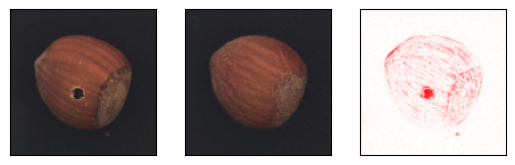

In [28]:
R_A = np.array(model.vae.decoder(np.array([zIN_mean]))[0])
plt.subplot(131);plt.imshow(I_A); plt.xticks([]); plt.yticks([]);
plt.subplot(132);plt.imshow(R_A); plt.xticks([]); plt.yticks([]);

anomaly_map = np.max(np.abs(R_A-I_A), axis=2)
am_max = np.max(anomaly_map)
plt.subplot(133); plt.imshow(anomaly_map, cmap='bwr', vmin=-am_max, vmax=am_max); plt.xticks([]); plt.yticks([])
print('am_max:',am_max)
plt.show()

In [29]:
# From "General Frameworks for Anomaly Detection Explainability: A comparative study"
# importlib.reload(ut)
from keras import backend as K
def mean_predict(model, data):
    z_mean, z_log_var, z = model.vae.encoder(data)
    reconstruction = model.vae.decoder(z_mean)
    return reconstruction
def lime_predict_loss(data, verbose=False):
    global model
    batch_size = K.shape(data)[0]
    reconstruction = mean_predict(model, data)
    MSE_loss = tf.reduce_sum(tf.square(reconstruction - data), axis=[1,2,3])
    return np.array([ [l] for l in MSE_loss ])

In [30]:
def lime_predict_loss(data, verbose=False):
    global model
    data = tf.convert_to_tensor(data, dtype=tf.float32)

    reconstruction = mean_predict(model, data)  # must return tf tensor float32
    mse = tf.reduce_sum(tf.square(reconstruction - data), axis=[1,2,3])  # (B,)

    return mse.numpy().reshape(-1, 1).astype(np.float32)  # (B,1) numeric!

In [31]:
score_functions     = [lime_predict_loss]

In [32]:
# def shap_bpt_masked_model(masks):
#     X = []
#     for m in masks:
#         m3 = m
#         img = R_A.copy()
#         img[m3] = I_A[m3]
#         X.append(img)
#     return np.array(lime_predict_loss(np.array(X)))

In [33]:
def shap_bpt_masked_model(masks):
    # masks: (B,H,W) or list of (H,W)
    X = []
    for m in masks:
        m = np.asarray(m, dtype=bool)          # <- critical
        img = np.array(R_A, copy=True)         # keeps dtype
        img[m] = I_A[m]
        X.append(img)

    X = np.asarray(X, dtype=np.float32)        # <- critical
    return lime_predict_loss(X)                # already (B,1) np.float32

In [34]:
f_0 = shap_bpt_masked_model(np.zeros((1,128,128), dtype=bool))[0,0]
f_S = shap_bpt_masked_model(np.ones((1,128,128), dtype=bool))[0,0]
print(f_S, f_0)

36.00169 3.982985


In [35]:
num_explained_classes = 1
batch_size = 16
num_samples= 500
verbose=True

# run_partial_test = False 
run_partial_test = True
evaluate_explanation = True

In [36]:
lime_predict_loss(np.expand_dims(I_A,axis=0))[0][0]

36.00169

# BPT

In [37]:
# how many black-box model evaluations f() we are willing to pay to get an Owen-explanation
MAX_EVALS_BUDGET      = 100
batch_size            = 4
num_explained_classes = 1
max_weight            = None
# 1/4 -> 10 reaches 16 terminals
# 1/16 -> 170 reaches 256 terminals
# 1/64 -> 2730 reaches 4096 terminals
# 1/256 -> 43690 reaches 65536 terminals

In [38]:
# def dbg_img(name, x):
#     import numpy as np
#     print(
#         name,
#         "dtype=", getattr(x, "dtype", None),
#         "shape=", getattr(x, "shape", None),
#         "min=", np.nanmin(x) if np.size(x) else None,
#         "max=", np.nanmax(x) if np.size(x) else None,
#         "finite=", np.isfinite(x).all() if isinstance(x, np.ndarray) else None,
#         "nan=", np.isnan(x).any() if isinstance(x, np.ndarray) else None,
#         "inf=", np.isinf(x).any() if isinstance(x, np.ndarray) else None,
#     )

# dbg_img("I_A", I_A)
# dbg_img("R_A", R_A)
# dbg_img("anomaly_map", anomaly_map)
# dbg_img("ground_truth", ground_truth)

In [39]:
# out = shap_bpt_masked_model([np.zeros((128,128), dtype=bool)])
# print(out.dtype, out.shape, out[:3])
# assert out.dtype != object
# assert out.shape[1] == 1

In [40]:
explainer = shap_bpt.Explainer(shap_bpt_masked_model, I_A_u8, num_explained_classes=num_explained_classes, verbose=True)
shap_values_bpt = explainer.explain_instance(num_samples, method='BPT', verbose_plot=False, 
                                                batch_size=batch_size)

  0%|          | 0/500 [00:00<?, ?it/s]

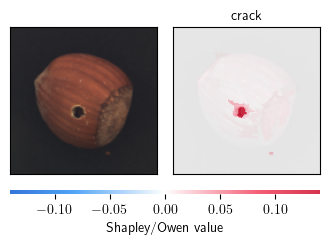

In [41]:
shap_bpt.plot_owen_values(explainer, shap_values_bpt, class_names)

In [42]:
print('Expected Shapley explanation: ', explainer.base_f_S[0] - explainer.base_f_0[0])
print('Computed Shapley explanation: ', np.sum(shap_values_bpt[0]))

Expected Shapley explanation:  32.018704891204834
Computed Shapley explanation:  32.018704891204834


# Axis-Aligned

In [43]:
explainer = shap_bpt.Explainer(shap_bpt_masked_model, I_A, num_explained_classes=num_explained_classes, verbose=True)
shap_values_aa = explainer.explain_instance(num_samples, method='AA', verbose_plot=False, 
                                                batch_size=batch_size)

  0%|          | 0/500 [00:00<?, ?it/s]

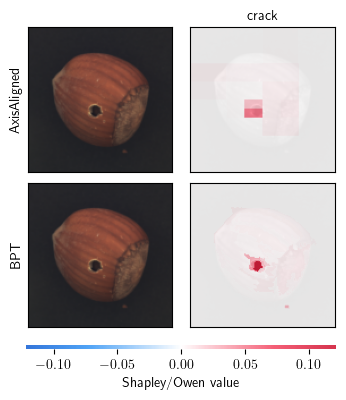

In [44]:
shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt], 
                          class_names, names=['AxisAligned','BPT'])

In [45]:
print('Expected Shapley explanation: ', explainer.base_f_S[0] - explainer.base_f_0[0])
print('Computed Shapley explanation: ', np.sum(shap_values_aa[0]))

Expected Shapley explanation:  32.018704891204834
Computed Shapley explanation:  32.018704891204834


1000 0.0625


  0%|          | 0/1000 [00:00<?, ?it/s]

Reached 256 terminals.


  0%|          | 0/1000 [00:00<?, ?it/s]

Reached 256 terminals.


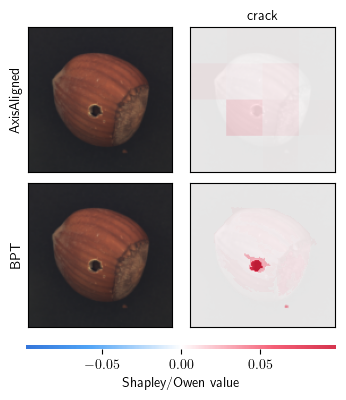

10 None


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

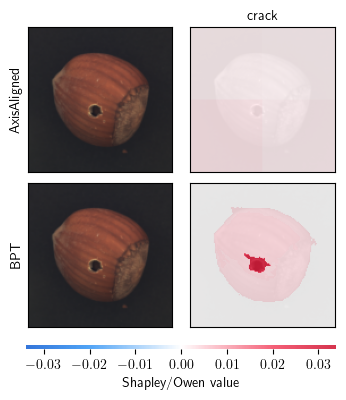

100 None


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

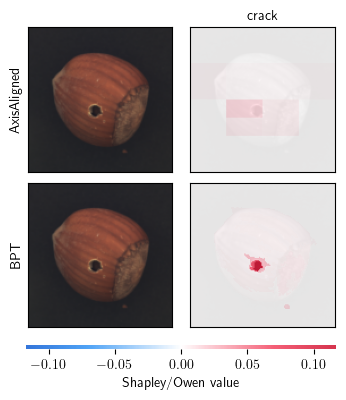

500 None


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

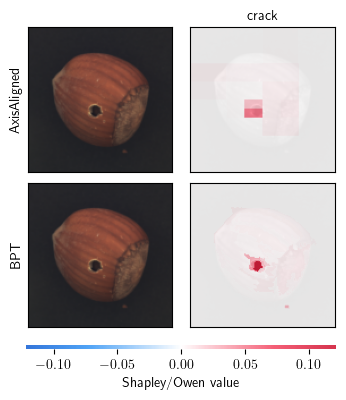

1000 None


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

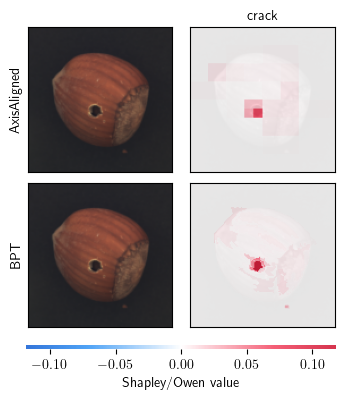

In [46]:
os.makedirs('saved_explanations',exist_ok=True)
for MAX_EVALS_BUDGET, max_weight in [(1000, 1/16), (10, None), (100, None), (500, None), (1000, None)]:
    print(MAX_EVALS_BUDGET, max_weight)
    # explainer = shap_bpt.Explainer(f_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)
    explainer = shap_bpt.Explainer(shap_bpt_masked_model, I_A, num_explained_classes=num_explained_classes, verbose=True)
    bptree = shap_bpt.build_bpt_from_image(I_A_u8)#, use_sqrt_area=False)
    shap_values_bpt = explainer.explain_instance(MAX_EVALS_BUDGET, method='BPT', bpt=bptree, verbose_plot=False, 
                                                 batch_size=batch_size, max_weight=max_weight)
    shap_values_aa = explainer.explain_instance(MAX_EVALS_BUDGET, method='AA', verbose_plot=False, 
                                                batch_size=batch_size, max_weight=max_weight)
    shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt], 
                              class_names, names=['AxisAligned','BPT'])
    
    wn = str(round(1/max_weight)) if max_weight is not None else 'None'
    np.savetxt(f'saved_explanations/shapley0bpt_{wn}_{MAX_EVALS_BUDGET}_{class_to_explain_name}_{image_to_explain_name}.txt', shap_values_bpt[0])
    np.savetxt(f'saved_explanations/shapley0aa_{wn}_{MAX_EVALS_BUDGET}_{class_to_explain_name}_{image_to_explain_name}.txt', shap_values_aa[0])

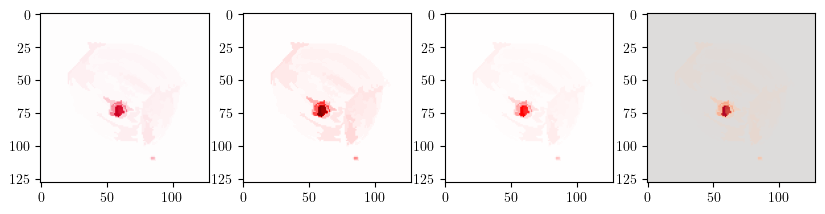

In [47]:
h = shap_values_bpt[0]
vmax = np.max(np.abs(h))
fig,axes = plt.subplots(1,4, figsize=(10,3))
for i, cm in enumerate([shap_bpt.shapley_values_colormap, 'seismic', 'bwr', 'coolwarm']):
    axes[i].imshow(h, cmap=cm, vmin=-vmax, vmax=vmax)
    # axes[i].set_title(cm)

# Loading and showing the computed explanations

In [48]:
suffix_lst = ['None_10', 'None_100', 'None_500', 'None_1000']

shapley_aa = dict()
shapley_bpt = dict()
vmax = 0.0
for sfx in suffix_lst:
    shapley_aa[sfx] = np.loadtxt(f'saved_explanations/shapley0aa_{sfx}_{class_to_explain_name}_{image_to_explain_name}.txt')
    shapley_bpt[sfx] = np.loadtxt(f'saved_explanations/shapley0bpt_{sfx}_{class_to_explain_name}_{image_to_explain_name}.txt')
    vmax = max(vmax, np.max(np.abs(shapley_aa[sfx])))
    vmax = max(vmax, np.max(np.abs(shapley_bpt[sfx])))
    
print(vmax)

0.14126921257758068


In [49]:
np.max(np.abs(shapley_aa[sfx]))/1000

7.911702957062516e-05

### FIGURE 3: A (AA & BPT)

0.11867554435593775


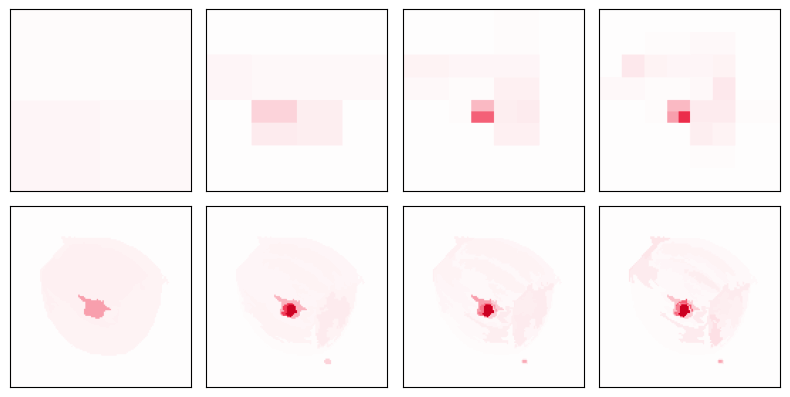

In [50]:
# vmax = 0.00022
# vmax = 1
threshold_scale = 1.5
vmax = np.abs(shapley_aa['None_1000']).max() *threshold_scale
print(vmax)
fig,ax = plt.subplots(2,len(suffix_lst), figsize=(len(suffix_lst)*2, 4.2))
for i,w in enumerate(suffix_lst):
    ax[0,i].imshow(shapley_aa[w], cmap=shap_bpt.shapley_values_colormap , vmin=-vmax, vmax=vmax)
    ax[1,i].imshow(shapley_bpt[w], cmap=shap_bpt.shapley_values_colormap, vmin=-vmax, vmax=vmax)
    for k in range(2):
        ax[k,i].set_xticks([]) ; ax[k,i].set_yticks([])

    plt.imshow
plt.tight_layout()
plt.savefig(f'paper_figures/figure_2_aa_bpt_saliencies.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

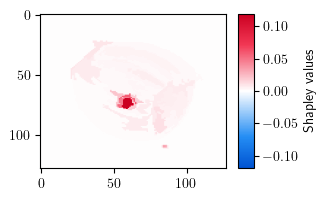

In [51]:
plt.figure(figsize=(3,2))
plt.imshow(shap_values_bpt[0], cmap=shap_bpt.shapley_values_colormap, aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(label='Shapley values', aspect=10)
# plt.title('Plot with Custom Colormap and Colorbar')
plt.savefig(f'paper_figures/colorbar.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

## Figure 1:A

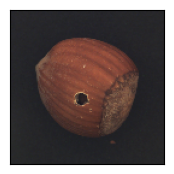

In [52]:
plt.figure(figsize=(2,2))
plt.imshow(image_to_explain); plt.xticks([]); plt.yticks([])
plt.savefig(f'paper_figures/figure_1_A.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

## Figure 1:B(AA & BPT)

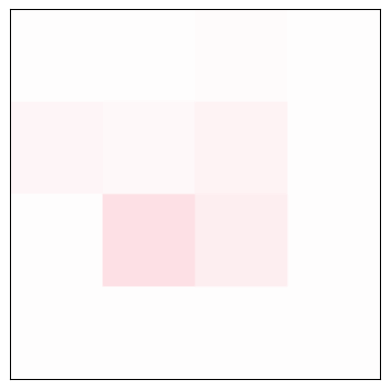

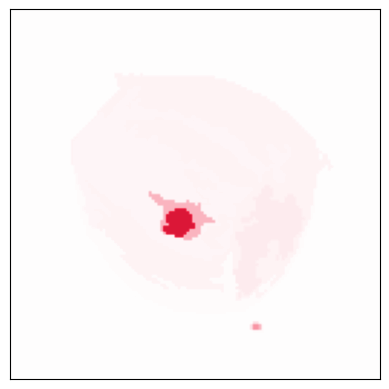

In [53]:
for name, img in [('aa4', np.loadtxt(f'saved_explanations/shapley0aa_16_1000_{class_to_explain_name}_{image_to_explain_name}.txt')), 
                  ('bpt4', np.loadtxt(f'saved_explanations/shapley0bpt_16_1000_{class_to_explain_name}_{image_to_explain_name}.txt'))]:
    plt.figure()
    plt.imshow(img, cmap=shap_bpt.shapley_values_colormap, vmin=-vmax, vmax=vmax)
    plt.xticks([]) ; plt.yticks([])
    plt.savefig(f'paper_figures/figure_1_B_{name}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
    plt.show()

# Evaluation

In [54]:
def saliency_to_auc(nu, heatmap, f_S, f_0, predicted_cls, batch_size=4, method='del', num_samples=101, 
                    rule='trapezoid'):
    assert isinstance(heatmap, np.ndarray)
    assert len(heatmap.shape)==2 and np.issubdtype(heatmap.dtype, np.floating)

    nu_max = max(f_S, f_0)
    nu_min = min(f_S, f_0)

    xs, ys, ms, masks, qs = [], [], [], [], []
    for i, value in enumerate(np.linspace(start=1.0, stop=0.0, num=num_samples)):
        if method=='del':
            epsilon = (1 if value==0.0 else 0)
            q = (np.quantile(heatmap, q=value) - epsilon)
            m = heatmap <= q
            nx = (1.0 - np.sum(m) / m.size)
        elif method=='ins':
            epsilon = (1 if value==1.0 else 0)
            q = (np.quantile(heatmap, q=value) + epsilon)
            m = heatmap >= q
            nx = (np.sum(m) / m.size)
        else:
            raise Exception()
            
        # add a new datapoint on the curve
        if len(xs)==0 or nx != xs[-1]: 
            assert m.dtype==bool and len(m.shape)==2
            xs.append(nx)
            masks.append(m)
            ms.append(np.sum(heatmap[m]))
            qs.append(q)

        # evaluate the characteristic function
        if len(masks) >= batch_size or (len(masks)>0 and i==(num_samples-1)):
            y = shap_bpt_masked_model(np.array(masks))[:, predicted_cls]
            ys.extend(y)
            masks = []

    assert len(masks)==0    
    xs, ys = np.array(xs), np.array(ys)
    assert(len(xs) == len(ys))

    # compute considering under/over shoots
    overshoot_max = np.maximum(0, ys - nu_max) # overshoot for values exceeding the maximum
    overshoot_min = np.maximum(0, nu_min - ys) # overshoot for values below the minimum
    # adjust ys with the overshoot. Clip it inside the admitted range
    y_adjusted = np.clip(ys - 2*overshoot_max + 2*overshoot_min, nu_min, nu_max)

    # rescaling
    ys_rescaled = (ys - nu_min) / (nu_max - nu_min)
    y_adjusted_rescaled = (y_adjusted - nu_min) / (nu_max - nu_min)

    auc, auc_r, auc_mae, auc_mse, auc_adj, auc_adjr = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

    curve_range = range(1, len(xs)) if rule=='trapezoid' else range(len(xs))

    # compute the area under the curve with the midpoint Riemann sum (i.e. the trapezoidal rule)
    for i in curve_range:
        if rule=='trapezoid':
            delta_x = abs(xs[i] - xs[i-1])
            assert delta_x > 0
            y_mid   =         0.5*(ys[i-1] + ys[i])
            y_r_mid =         0.5*(ys_rescaled[i-1] + ys_rescaled[i])
            err_mid = y_mid - 0.5*(ms[i-1] - ms[i])
            y_adj_mid =       0.5*(y_adjusted[i-1] + y_adjusted[i])
            y_adjr_mid =      0.5*(y_adjusted_rescaled[i-1] + y_adjusted_rescaled[i])
        else: # rectangles
            delta_x = 1.0/num_samples if i==len(xs)-1 else abs(xs[i+1] - xs[i])
            assert delta_x > 0
            y_mid   =         ys[i]
            y_r_mid =         ys_rescaled[i]
            err_mid = y_mid - ms[i]
            y_adj_mid =       y_adjusted[i]
            y_adjr_mid =      y_adjusted_rescaled[i]


        auc += abs(delta_x * y_mid) # base * height
        auc_r += abs(delta_x * y_r_mid) # base * height
        # auc_eff += abs(delta_x * err_mid) # base * height
        auc_mae += abs(delta_x * err_mid) # base * height
        auc_mse += abs(delta_x * (err_mid**2)) # base * height^2
        auc_adj += abs(delta_x * y_adj_mid)
        auc_adjr += abs(delta_x * y_adjr_mid)

    return {'xs':xs, 'ys':ys, 'ms':ms, 'qs':qs, 'ysr':ys_rescaled,
            'y_adj':y_adjusted, 'y_adjr':y_adjusted_rescaled, 
            'method':method, #'class_id':class_id,
            'auc':auc, 'auc_r':auc_r, #'auc_eff':auc_eff, 
            'auc_mae':auc_mae, 'auc_mse':auc_mse, 'auc_rmse':np.sqrt(auc_mse), 
            'auc_adj':auc_adj, 'auc_adjr':auc_adjr}

In [55]:
def calc_IoU_curve(y_true, y_pred):
    assert isinstance(y_true, np.ndarray)
    assert isinstance(y_pred, np.ndarray)
    assert len(y_true.shape)==1 and len(y_pred.shape)==1 # assumes y_true and y_pred to be flattened arrays
    assert len(y_true)==len(y_pred)
    assert y_true.dtype==np.dtype('bool') and np.issubdtype(y_pred.dtype, np.floating)

    yd   = np.array(sorted(zip(y_pred, y_true), reverse=True))
    X2   = np.zeros(len(y_pred))
    IoU2 = np.zeros(len(y_pred))
    Th   = np.zeros(len(y_pred))
    
    nT = np.sum(y_true)
    nInt = 0
    for i in range(len(y_pred)):
        if yd[i,1]: 
            nInt += 1
        
        IoU2[i] = nInt / (i + nT - nInt)
        X2[i] = i
        Th[i] = yd[i,0]
        
    X2 = X2 / len(y_pred)
    auc_IoU = 0
    for i in range(1, len(y_pred)):
        auc_IoU += (X2[i] - X2[i-1]) * (IoU2[i] + IoU2[i-1]) / 2.0
    
    best_pt = np.argmax(IoU2)
    return {'X':X2, 'Y':IoU2, 'max_IoU_heatmap_threshold':Th[best_pt], 
            'max_IoU_score':IoU2[best_pt], 'x_best':X2[best_pt], 'auc_IoU':auc_IoU}

In [56]:
# selected_sfx = 'None_1000'
# shapley_values_aa = shapley_aa[selected_sfx]
# shapley_values_bpt = shapley_bpt[selected_sfx]
# print(shapley_values_aa.shape)

selected_sfx, shapley_values_aa, shapley_values_bpt = 'BASIC', shap_values_aa[0], shap_values_bpt[0]

In [57]:
f_0 = shap_bpt_masked_model(np.zeros((1,128,128), dtype=bool))[0,0]
f_S = shap_bpt_masked_model(np.ones((1,128,128), dtype=bool))[0,0]
print(f_S, f_0)

36.00169 3.982985


In [58]:
# shapley_values_aa = shap_values_aa[0]
# shapley_values_bpt = shap_values_bpt[0]
f_S, f_0

(36.00169, 3.982985)

In [59]:
# aucD_aa = saliency_to_auc(f_masked, shapley_values_aa, f_S, f_0, predicted_cls, method='del')
# aucD_bpt = saliency_to_auc(f_masked, shapley_values_bpt, f_S, f_0, predicted_cls, method='del')
# aucI_aa = saliency_to_auc(f_masked, shapley_values_aa, f_S, f_0, predicted_cls, method='ins')
# aucI_bpt = saliency_to_auc(f_masked, shapley_values_bpt, f_S, f_0, predicted_cls, method='ins')

aucD_aa =   saliency_to_auc(shap_bpt_masked_model,shapley_values_aa,f_S, f_0, predicted_cls=0, method='del', batch_size=batch_size)
aucD_bpt =  saliency_to_auc(shap_bpt_masked_model,shapley_values_bpt,f_S, f_0, predicted_cls=0, method='del', batch_size=batch_size)

aucI_aa =   saliency_to_auc(shap_bpt_masked_model,shapley_values_aa,f_S, f_0, predicted_cls=0, method='ins', batch_size=batch_size)
aucI_bpt =  saliency_to_auc(shap_bpt_masked_model,shapley_values_bpt,f_S, f_0, predicted_cls=0, method='ins', batch_size=batch_size)

# aucI_aa =


# aucD_aa = saliency_to_auc(shapley_values_aa, method='del')
# aucD_bpt = saliency_to_auc(shapley_values_bpt, method='del')
# aucI_aa = saliency_to_auc(shapley_values_aa, method='ins')
# aucI_bpt = saliency_to_auc(shapley_values_bpt, method='ins')
auc_IoU_aa = calc_IoU_curve(ground_truth.flatten(), shapley_values_aa.flatten())
auc_IoU_bpt = calc_IoU_curve(ground_truth.flatten(), shapley_values_bpt.flatten())

## Figure 3: B

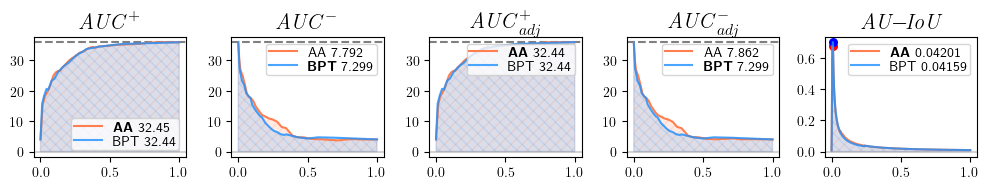

In [60]:
fig,axes = plt.subplots(1,5, figsize=(10,2), sharex=True)#, sharey=True) #3,3  figsize=(8,2.2)

for i in range(5):
    ax = axes.flat[i]
    if i==0: # insertion/regression
        title='$\\mathit{AUC}^{+}$'
        Xa,Ya,Ma,La = aucI_aa['xs'], aucI_aa['ys'], aucI_aa['ms'], aucI_aa['auc']
        Xb,Yb,Mb,Lb = aucI_bpt['xs'], aucI_bpt['ys'], aucI_bpt['ms'], aucI_bpt['auc']
        # Xa,Ya,Ma,La = aucI_aa[0], aucI_aa[1], aucI_aa[2], aucI_aa[3]
        # Xb,Yb,Mb,Lb = aucI_bpt[0], aucI_bpt[1], aucI_bpt[2], aucI_bpt[3]
    elif i==1: # deletion/regression
        title='$\\mathit{AUC}^{-}$'
        Xa,Ya,Ma,La = aucD_aa['xs'], aucD_aa['ys'], aucD_aa['ms'], aucD_aa['auc']
        Xb,Yb,Mb,Lb = aucD_bpt['xs'], aucD_bpt['ys'], aucD_bpt['ms'], aucD_bpt['auc']
        # Xa,Ya,Ma,La = aucD_aa[0], aucD_aa[1], aucD_aa[2], aucD_aa[3]
        # Xb,Yb,Mb,Lb = aucD_bpt[0], aucD_bpt[1], aucD_bpt[2], aucD_bpt[3]
    elif i==2: # AUC+adj
        title='$\\mathit{AUC}^{+}_{adj}$'
        Xa,Ya,Ma,La = aucI_aa['xs'], aucI_aa['y_adj'], aucI_aa['ms'], aucI_aa['auc_adj']
        Xb,Yb,Mb,Lb = aucI_bpt['xs'], aucI_bpt['y_adj'], aucI_bpt['ms'], aucI_bpt['auc_adj']
    elif i==3: # AUC-adj
        title='$\\mathit{AUC}^{-}_{adj}$'
        Xa,Ya,Ma,La = aucD_aa['xs'], aucD_aa['y_adj'], aucD_aa['ms'], aucD_aa['auc_adj']
        Xb,Yb,Mb,Lb = aucD_bpt['xs'], aucD_bpt['y_adj'], aucD_bpt['ms'], aucD_bpt['auc_adj']
    # elif i==2: # insertion/error
    #     title='$\\mathit{MSE}^{+}$'
    #     Xa,Ya,Ma,La = aucI_aa[0], (aucI_aa[1]-aucI_aa[2])**2, aucI_aa[2], aucI_aa[5]
    #     Xb,Yb,Mb,Lb = aucI_bpt[0], (aucI_bpt[1]-aucI_bpt[2])**2, aucI_bpt[2], aucI_bpt[5]
    # elif i==3: # deletion/error
    #     title='$\\mathit{MSE}^{-}$'
    #     Xa,Ya,Ma,La = aucD_aa[0], (aucD_aa[1]-aucD_aa[2])**2, aucD_aa[2], aucD_aa[5]
    #     Xb,Yb,Mb,Lb = aucD_bpt[0], (aucD_bpt[1]-aucD_bpt[2])**2, aucD_bpt[2], aucD_bpt[5]
    elif i==4: # IoU
        title='$\\mathit{AU}{\!-\!}\\mathit{IoU}$'
        # return X2, IoU2, Th[best_pt], X2[best_pt], auc_IoU
        Xa,Ya,Ma,La = auc_IoU_aa['X'], auc_IoU_aa['Y'], None, auc_IoU_aa['auc_IoU']
        Xb,Yb,Mb,Lb = auc_IoU_bpt['X'], auc_IoU_bpt['Y'], None, auc_IoU_bpt['auc_IoU']
        xma, yma = auc_IoU_aa['x_best'], np.max(auc_IoU_aa['Y'])
        xmb, ymb = auc_IoU_bpt['x_best'], np.max(auc_IoU_bpt['Y'])
        # Xa,Ya,Ma,La = auc_IoU_aa[0], auc_IoU_aa[1], None, auc_IoU_aa[4]
        # Xb,Yb,Mb,Lb = auc_IoU_bpt[0], auc_IoU_bpt[1], None, auc_IoU_bpt[4]
        # xma, yma = auc_IoU_aa[3], np.max(auc_IoU_aa[1])
        # xmb, ymb = auc_IoU_bpt[3], np.max(auc_IoU_bpt[1])

    Sa, Sb = ('\\textbf', '') if La<Lb else ('', '\\textbf')
    if i in [0,2,4]:   Sa,Sb=Sb,Sa
    ax.plot(Xa, Ya, c='coral', label=f'{Sa}{{AA}} {La:.4}')
    ax.fill_between(Xa, Ya, color='coral', alpha=0.15, hatch='///')
    # ax.scatter(Xa, Ya, c='black', s=5)
    ax.plot(Xb, Yb, c='dodgerblue', label=f'{Sb}{{BPT}} {Lb:.4}', alpha=0.80)
    ax.fill_between(Xb, Yb, color='dodgerblue', alpha=0.15, hatch='\\\\\\')
    
    if i==4: # IoU
        ax.scatter(xma, yma, s=30, color='red')
        ax.scatter(xmb, ymb, s=30, color='blue')
    else:
        ax.axhline(f_S, ls='--', c='grey', zorder=0)
    
    ax.axhline(0, c='lightgrey', zorder=0)
    ax.legend(borderpad=0.2, labelspacing=0.1, loc='upper right' if i>=1 else 'lower right')#, bbox_to_anchor=(1,0))
    ax.set_title(title, fontsize=16)

plt.tight_layout()
# plt.savefig(f'paper_figures/figure_2_B_five_metrics.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

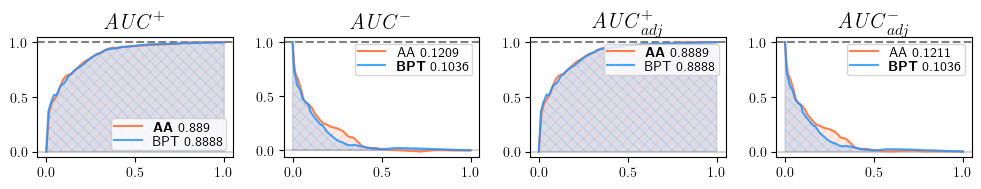

In [61]:
fig,axes = plt.subplots(1,4, figsize=(10,2), sharex=True)#, sharey=True) #3,3  figsize=(8,2.2)

for i in range(4):
    ax = axes.flat[i]
    if i==0: # insertion/regression
        title='$\\mathit{AUC}^{+}$'
        Xa,Ya,Ma,La = aucI_aa['xs'], aucI_aa['ysr'], aucI_aa['ms'], aucI_aa['auc_r']
        Xb,Yb,Mb,Lb = aucI_bpt['xs'], aucI_bpt['ysr'], aucI_bpt['ms'], aucI_bpt['auc_r']
    elif i==1: # deletion/regression
        title='$\\mathit{AUC}^{-}$'
        Xa,Ya,Ma,La = aucD_aa['xs'], aucD_aa['ysr'], aucD_aa['ms'], aucD_aa['auc_r']
        Xb,Yb,Mb,Lb = aucD_bpt['xs'], aucD_bpt['ysr'], aucD_bpt['ms'], aucD_bpt['auc_r']
    elif i==2: # AUC+adj
        title='$\\mathit{AUC}^{+}_{adj}$'
        Xa,Ya,Ma,La = aucI_aa['xs'], aucI_aa['y_adjr'], aucI_aa['ms'], aucI_aa['auc_adjr']
        Xb,Yb,Mb,Lb = aucI_bpt['xs'], aucI_bpt['y_adjr'], aucI_bpt['ms'], aucI_bpt['auc_adjr']
    elif i==3: # AUC-adj
        title='$\\mathit{AUC}^{-}_{adj}$'
        Xa,Ya,Ma,La = aucD_aa['xs'], aucD_aa['y_adjr'], aucD_aa['ms'], aucD_aa['auc_adjr']
        Xb,Yb,Mb,Lb = aucD_bpt['xs'], aucD_bpt['y_adjr'], aucD_bpt['ms'], aucD_bpt['auc_adjr']

    Sa, Sb = ('\\textbf', '') if La<Lb else ('', '\\textbf')
    if i in [0,2]:   Sa,Sb=Sb,Sa
    ax.plot(Xa, Ya, c='coral', label=f'{Sa}{{AA}} {La:.4}')
    ax.fill_between(Xa, Ya, color='coral', alpha=0.15, hatch='///')
    # ax.scatter(Xa, Ya, c='black', s=5)
    ax.plot(Xb, Yb, c='dodgerblue', label=f'{Sb}{{BPT}} {Lb:.4}', alpha=0.80)
    ax.fill_between(Xb, Yb, color='dodgerblue', alpha=0.15, hatch='\\\\\\')
    
    ax.axhline(1.0, ls='--', c='grey', zorder=0)
    
    ax.axhline(0, c='lightgrey', zorder=0)
    ax.legend(borderpad=0.2, labelspacing=0.1, loc='upper right' if i>=1 else 'lower right')#, bbox_to_anchor=(1,0))
    ax.set_title(title, fontsize=16)

plt.tight_layout()
# plt.savefig(f'paper_figures/figure_2_B_five_metrics.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [62]:
auc_IoU_aa

{'X': array([0.00000000e+00, 6.10351562e-05, 1.22070312e-04, ...,
        9.99816895e-01, 9.99877930e-01, 9.99938965e-01]),
 'Y': array([0.00680272, 0.01360544, 0.02040816, ..., 0.00903486, 0.00903431,
        0.00903375]),
 'max_IoU_heatmap_threshold': 0.024820219739922322,
 'max_IoU_score': 0.6737967914438503,
 'x_best': 0.01007080078125,
 'auc_IoU': 0.042008075926152216}

## save plots as independent pictures

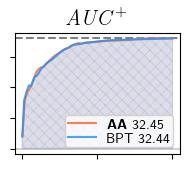

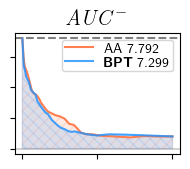

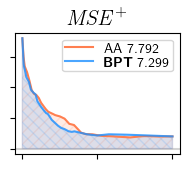

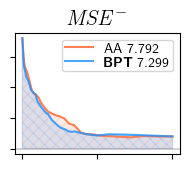

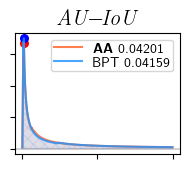

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# fig, axes = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

titles = [
    '$\\mathit{AUC}^{+}$',
    '$\\mathit{AUC}^{-}$',
    '$\\mathit{MSE}^{+}$',
    '$\\mathit{MSE}^{-}$',
    '$\\mathit{AU}{\!-\!}\\mathit{IoU}$'
]

for i in range(5):
    fig, ax = plt.subplots(figsize=(2,1.8 ))  # Adjust figure size as needed

    if i == 0:  # insertion/regression
        # auc_['xs'], auc_['ys'],     auc_['ms'], auc_['auc']
        Xa, Ya, Ma, La = aucI_aa['xs'], aucI_aa['ys'], aucI_aa['ms'], aucI_aa['auc']
        Xb, Yb, Mb, Lb = aucI_bpt['xs'], aucI_bpt['ys'], aucI_bpt['ms'], aucI_bpt['auc']
    elif i == 1:  # deletion/regression
        Xa, Ya, Ma, La = aucD_aa['xs'], aucD_aa['ys'], aucD_aa['ms'], aucD_aa['auc']
        Xb, Yb, Mb, Lb = aucD_bpt['xs'], aucD_bpt['ys'], aucD_bpt['ms'], aucD_bpt['auc']
    # elif i == 2:  # insertion/error
        # Xa, Ya, Ma, La = aucI_aa[0], (aucI_aa[1] - aucI_aa[2]) ** 2, aucI_aa[2], aucI_aa[5]
        # Xb, Yb, Mb, Lb = aucI_bpt[0], (aucI_bpt[1] - aucI_bpt[2]) ** 2, aucI_bpt[2], aucI_bpt[5]
    # elif i == 3:  # deletion/error
        # Xa, Ya, Ma, La = aucD_aa[0], (aucD_aa[1] - aucD_aa[2]) ** 2, aucD_aa[2], aucD_aa[5]
        # Xb, Yb, Mb, Lb = aucD_bpt[0], (aucD_bpt[1] - aucD_bpt[2]) ** 2, aucD_bpt[2], aucD_bpt[5]
    elif i == 4:  # IoU
        Xa,Ya,Ma,La = auc_IoU_aa['X'], auc_IoU_aa['Y'], None, auc_IoU_aa['auc_IoU']
        Xb,Yb,Mb,Lb = auc_IoU_bpt['X'], auc_IoU_bpt['Y'], None, auc_IoU_bpt['auc_IoU']
        xma, yma = auc_IoU_aa['x_best'], np.max(auc_IoU_aa['Y'])
        xmb, ymb = auc_IoU_bpt['x_best'], np.max(auc_IoU_bpt['Y'])

    Sa, Sb = ('\\textbf', '') if La < Lb else ('', '\\textbf')
    if i in [0, 4]:
        Sa, Sb = Sb, Sa

    ax.plot(Xa, Ya, c='coral', label=f'{Sa}{{AA}} {La:.4}')
    ax.fill_between(Xa, Ya, color='coral', alpha=0.15, hatch='///')
    ax.plot(Xb, Yb, c='dodgerblue', label=f'{Sb}{{BPT}} {Lb:.4}', alpha=0.80)
    ax.fill_between(Xb, Yb, color='dodgerblue', alpha=0.15, hatch='\\\\\\')

    if i == 4:
        ax.scatter(xma, yma, s=30, color='red')
        ax.scatter(xmb, ymb, s=30, color='blue')
    if i < 2:
        ax.axhline(f_S, ls='--', c='grey', zorder=0)

    ax.axhline(0, c='lightgrey', zorder=0)
    ax.legend(borderpad=0.2, labelspacing=0.1, loc='upper right' if i >= 1 else 'lower right')
    ax.set_title(titles[i], fontsize=16)
    # ax.set_yticks([0.0,0.25,0.5,0.75])
    # ax.set_xticks([0,50,100])
    
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    plt.tight_layout()
    plt.savefig(f'paper_figures/figure_2_B_metric_{i+1}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
    plt.show()
    # plt.close(fig)  # Close figure to free memory


# Visualize the coalitions 

In [370]:
from skimage.segmentation import mark_boundaries

In [371]:
%%time
bptree = shap_bpt.build_bpt_from_image(image_to_explain.astype('uint8'))

CPU times: total: 78.1 ms
Wall time: 78 ms


In [372]:
def colorize(nodes, img, i):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    pxflat_image = image_to_explain.reshape((img.shape[0] * img.shape[1], 3))
    colored = np.zeros_like(image_to_explain, dtype=np.float32)
    flat_colored = colored.reshape(pxflat_image.shape)
    for node in nodes:
        if is_aa:
            clr = np.mean(np.mean(image_to_explain[node.ymin:node.ymax, node.xmin:node.xmax, :], axis=1), axis=0)/255.0
            colored[ node.ymin:node.ymax, node.xmin:node.xmax ] = clr
        else:
            s,e = node.pixels_interval()
            clr = np.mean(pxflat_image[ node.bpt.pixels[s:e] ], axis=0)/255.0
            flat_colored[ node.bpt.pixels[s:e], :: ] = clr #np.array(cmap[s % len(cmap)])[0:3]
    return colored

def make_segments(nodes, img):
    is_aa = isinstance(nodes[0], shap_bpt.AxisAlignedSegment)
    flat_img = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint32)
    for i, node in enumerate(nodes):
        if is_aa:
            flat_img[ node.ymin:node.ymax, node.xmin:node.xmax ] = i
        else:
            s,e = node.pixels_interval()
            flat_img.ravel()[ node.bpt.pixels[s:e] ] = i
    return flat_img#.reshape((img.shape[0], img.shape[1]))

## FIGURE 1:C(AA)

In [399]:
image_to_explain = I_A_u8

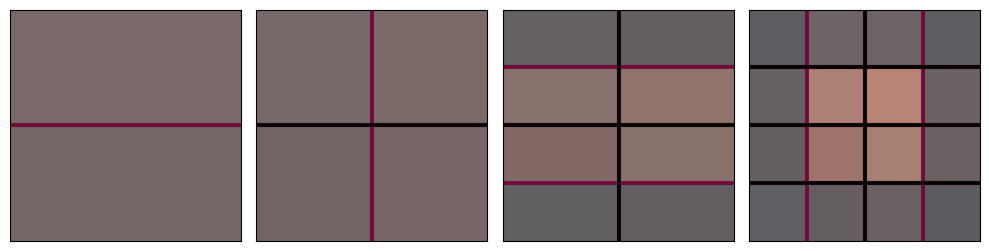

In [400]:
base_segment = shap_bpt.BaseSegment()
root_node, name = shap_bpt.AxisAlignedSegment(0, bptree.width, 0, bptree.height, base_segment), 'AA'
#root_node, name = shap_bpt.BPT_Segment(bptree, bptree.N-1, base_segment), 'BPT'
segments = [root_node]
all_nodes = [root_node]
prev_boundaries = None

def expand_tree(segments, all_nodes):
    new_segments = []
    for s in segments:
        split = s.split(s, s)
        if split is None:
            new_segments.append(s)
            leaves[ii] += 1
        else:
            new_segments.extend(split)
            all_nodes.extend(split)
    return new_segments

K=4
leaves = np.zeros(K, dtype=int)
fig, axes = plt.subplots(1,(K), figsize=(10,4))
for ii in range(0,K+1):
    img = colorize(segments, image_to_explain, 0)
    img = np.clip(0.2 + img * 1.1, 0, 1)
    sgm = make_segments(segments, image_to_explain)
    cut_color = (.5, 0, .25, 1)
    boundaries = mark_boundaries(np.tile((255,255,255,0), (image_to_explain.shape[0],image_to_explain.shape[1],1)), sgm, 
                                 mode='thick', color=cut_color)
    
    if ii>=1:# and ii%2==0:
        ax = axes.flatten()[(ii)-1]
        ax.set_xticks([]) ; ax.set_yticks([])
        ax.imshow(img)#, alpha=0.75)
        ax.imshow(boundaries)
        nshape = (128*128, 4)
        boundaries.reshape(nshape)[ np.where(boundaries.reshape(nshape) == cut_color)[0] ] = (0,0,0,1)
        if prev_boundaries is not None:
            ax.imshow(prev_boundaries)
#         ax.set_title(f'depth={ii}, $n$={len(segments)}', fontsize=20)

    prev_boundaries = boundaries
    segments = expand_tree(segments, all_nodes)

plt.tight_layout()
plt.savefig(f'paper_figures/figure1_C_{name}_expansion.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

## FIGURE 1:C(BPT)

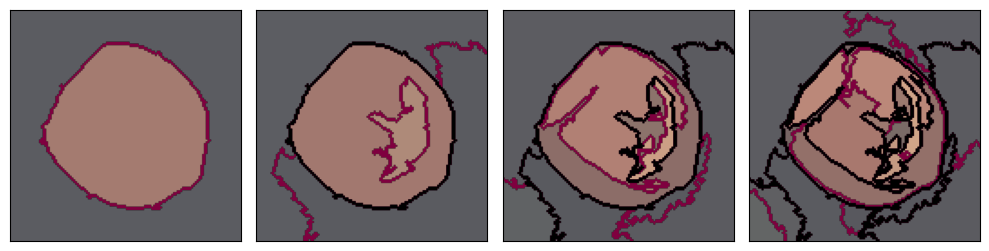

In [401]:
base_segment = shap_bpt.BaseSegment()
# root_node, name = shap_bpt.AxisAlignedSegment(0, bptree.width, 0, bptree.height, base_segment), 'AA'
root_node, name = shap_bpt.BPT_Segment(bptree, bptree.N-1, base_segment), 'BPT'
segments = [root_node]
all_nodes = [root_node]
prev_boundaries = None

def expand_tree(segments, all_nodes):
    new_segments = []
    for s in segments:
        split = s.split(s, s)
        if split is None:
            new_segments.append(s)
            leaves[ii] += 1
        else:
            new_segments.extend(split)
            all_nodes.extend(split)
    return new_segments

K=4
leaves = np.zeros(K, dtype=int)
fig, axes = plt.subplots(1,(K), figsize=(10,4))
for ii in range(0,K+1):
    img = colorize(segments, image_to_explain, 0)
    img = np.clip(0.2 + img * 1.1, 0, 1)
    sgm = make_segments(segments, image_to_explain)
    cut_color = (.5, 0, .25, 1)
    boundaries = mark_boundaries(np.tile((255,255,255,0), (image_to_explain.shape[0],image_to_explain.shape[1],1)), sgm, 
                                 mode='thick', color=cut_color)
    
    if ii>=1:# and ii%2==0:
        ax = axes.flatten()[(ii)-1]
        ax.set_xticks([]) ; ax.set_yticks([])
        ax.imshow(img)#, alpha=0.75)
        ax.imshow(boundaries)
        nshape = (128*128, 4)
        boundaries.reshape(nshape)[ np.where(boundaries.reshape(nshape) == cut_color)[0] ] = (0,0,0,1)
        if prev_boundaries is not None:
            ax.imshow(prev_boundaries)
#         ax.set_title(f'depth={ii}, $n$={len(segments)}', fontsize=20)

    prev_boundaries = boundaries
    segments = expand_tree(segments, all_nodes)

plt.tight_layout()
plt.savefig(f'paper_figures/figure1_C_{name}_expansion.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

# Recursive patches

In [402]:
importlib.reload(shap_bpt)
def empty_nu(img):
    return np.zeros((3,1))
explainer = shap_bpt.Explainer(empty_nu, image_to_explain, num_explained_classes=3, verbose=False)

targets = []
def enum_targets(aa, depth):
    if depth==0:
        targets.append(aa)
    else:
        aa1, aa2 = aa.split(None, None)
        enum_targets(aa1, depth-1)
        enum_targets(aa2, depth-1)

In [403]:
s0 = shap_bpt.BPT_Segment(bptree, bptree.N-1, None) ; 
enum_targets(s0, 4)

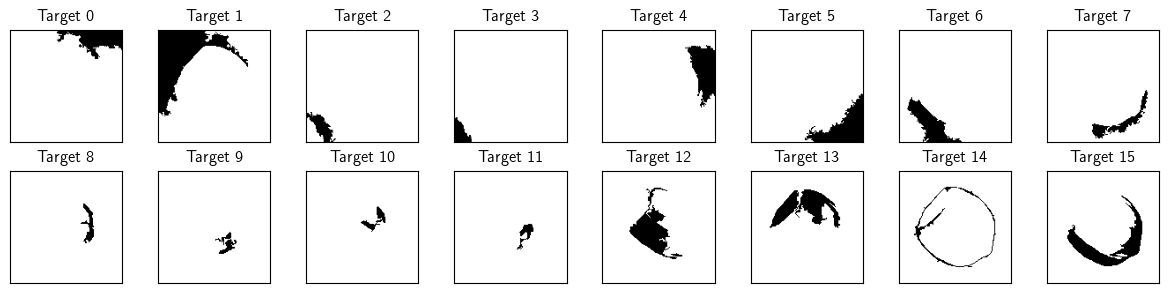

In [404]:
nr, nc = 2, 8
fig, axes = plt.subplots(nr, nc, figsize=(nc*1.5, nr*1.5))
for i in range(nr * nc):
    ax = axes[i // nc, i % nc]
    mask = np.zeros(image_to_explain.shape[:2], dtype=np.uint8)
    targets[i].fill_mask(mask, False)
    ax.imshow(~mask, cmap='gray')
    ax.set_title(f'Target {i}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [405]:
coal_num = 8 ; coal_t='bpt'
# coal_num = 10 ; coal_t='bpt'

In [406]:
list_of_patches = None
def Phi(S, T):
    global explainer, list_of_patches
    for Ci in S:
        if Ci.equals(T):
            mask = explainer.empty_mask()
            patch_num = 1
            for C in S:
                if not C.equals(T):
                    C.fill_mask(mask, False)
            vS = explainer.predict_masked([mask])
            if list_of_patches is not None:
                list_of_patches.append((mask, Ci))
            Ci.fill_mask(mask, False)
            return
        elif Ci.contains(T):
            Si = [Cj for Cj in S if not Cj.equals(Ci)]
            Ci1, Ci2 = Ci.split(None, None)
            if Ci2.contains(T):
                Ci1, Ci2 = Ci2, Ci1
                
            Phi(Si + [Ci1], T)
            Phi(Si + [Ci1, Ci2], T)
            return
    assert False

In [407]:
def get_list_of_patches(S, T):
    global list_of_patches
    list_of_patches = []
    Phi(S, T)
    l, list_of_patches = list_of_patches, None
    return l

lp = get_list_of_patches([s0], targets[coal_num])
print(len(targets), len(lp))

16 16


### Figure 1 : D (BPT)

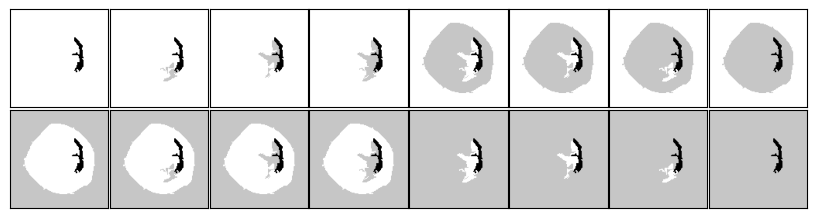

In [408]:
nr, nc = len(lp)//8, 8
fig,axes = plt.subplots(nr, nc, figsize=(nc, 1.05*nr))
for i, (mask,C) in enumerate(lp):
    ax = axes.ravel()[i]
    ax.imshow(mask, cmap='Greys', vmin=0, vmax=3)
    C.plot(ax, color=(0,0,0,1.0))
    ax.set_xticks([]) ; ax.set_yticks([])
plt.tight_layout(pad=0.1)
plt.savefig(f'paper_figures/figure1_D_coalitions_{coal_t}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

### Figure 1 : D (AA)

In [409]:
importlib.reload(shap_bpt)
def empty_nu(img):
    return np.zeros((3,1))
explainer = shap_bpt.Explainer(empty_nu, image_to_explain, num_explained_classes=3, verbose=False)

targets = []
def enum_targets(aa, depth):
    if depth==0:
        targets.append(aa)
    else:
        aa1, aa2 = aa.split(None, None)
        enum_targets(aa1, depth-1)
        enum_targets(aa2, depth-1)

In [410]:
s0 = shap_bpt.AxisAlignedSegment(0, image_to_explain.shape[0], 0,image_to_explain.shape[1], None) ; 
enum_targets(s0, 4)

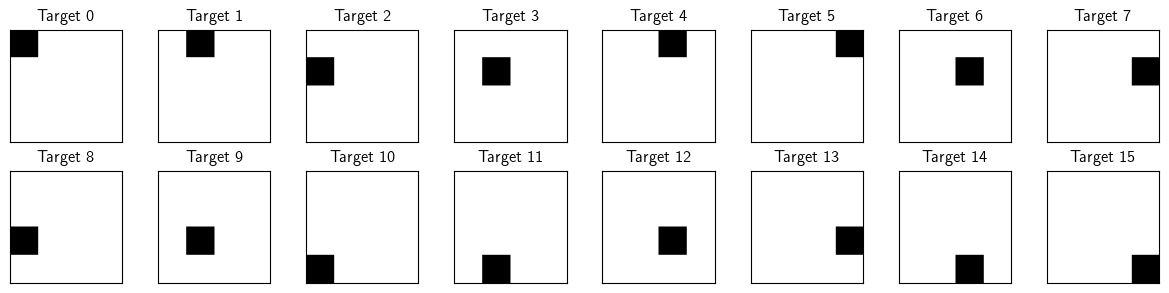

In [411]:
nr, nc = 2, 8
fig, axes = plt.subplots(nr, nc, figsize=(nc*1.5, nr*1.5))
for i in range(nr * nc):
    ax = axes[i // nc, i % nc]
    mask = np.zeros(image_to_explain.shape[:2], dtype=np.uint8)
    targets[i].fill_mask(mask, False)
    ax.imshow(~mask, cmap='gray')
    ax.set_title(f'Target {i}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [412]:
coal_num = 8 ; coal_t='aa'
# coal_num = 6 ; coal_t='aa'

In [413]:
list_of_patches = None
def Phi(S, T):
    global explainer, list_of_patches
    for Ci in S:
        if Ci.equals(T):
            mask = explainer.empty_mask()
            patch_num = 1
            for C in S:
                if not C.equals(T):
                    C.fill_mask(mask, False)
            vS = explainer.predict_masked([mask])
            if list_of_patches is not None:
                list_of_patches.append((mask, Ci))
            Ci.fill_mask(mask, False)
            return
        elif Ci.contains(T):
            Si = [Cj for Cj in S if not Cj.equals(Ci)]
            Ci1, Ci2 = Ci.split(None, None)
            if Ci2.contains(T):
                Ci1, Ci2 = Ci2, Ci1
                
            Phi(Si + [Ci1], T)
            Phi(Si + [Ci1, Ci2], T)
            return
    assert False

In [414]:
lp = get_list_of_patches([s0], targets[coal_num])
print(len(targets), len(lp))

16 16


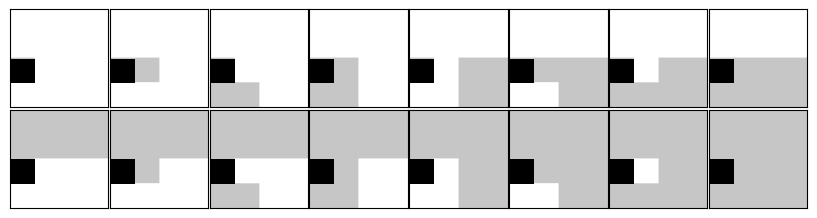

In [415]:
nr, nc = len(lp)//8, 8
fig,axes = plt.subplots(nr, nc, figsize=(nc, 1.05*nr))
for i, (mask,C) in enumerate(lp):
    ax = axes.ravel()[i]
    ax.imshow(mask, cmap='Greys', vmin=0, vmax=3)
    C.plot(ax, color=(0,0,0,1.0))
    ax.set_xticks([]) ; ax.set_yticks([])
plt.tight_layout(pad=0.1)
plt.savefig(f'paper_figures/figure1_D_coalitions_{coal_t}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

# Ground truth visualization

In [416]:
def vis_IoU(shapley_values, threshold, ground_truth):
    pred = shapley_values.flatten() >= threshold
    real = ground_truth.flatten()
    image = np.full((len(pred), 3), 255, dtype=np.float32)

    image[ pred & real, : ]    = (0.0, 0.0, 0.75) # True Positives
    image[ pred & (~real), : ] = (1.0, 0.6, 0.2) # False Positives
    image[ (~pred) & real, : ] = (1.0, 0.4, 1.0) # False Negatives

    return image.reshape(list(ground_truth.shape) + [3])

### Figure 3: C (GT)

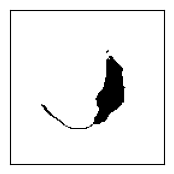

In [417]:
plt.figure(figsize=(2,2))
plt.imshow(ground_truth, cmap='Greys')
plt.xticks([]) ; plt.yticks([])
plt.savefig(f'paper_figures/figure_2_C_IoU_.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

### Figure 3: C (AA)

In [418]:
auc_IoU_aa

{'X': array([0.00000000e+00, 6.10351562e-05, 1.22070312e-04, ...,
        9.99816895e-01, 9.99877930e-01, 9.99938965e-01]),
 'Y': array([0.00110619, 0.00221239, 0.00331858, ..., 0.05524693, 0.05524356,
        0.05524019]),
 'max_IoU_heatmap_threshold': 0.023411330999806523,
 'max_IoU_score': 0.6556808326105811,
 'x_best': 0.061279296875,
 'auc_IoU': 0.16514968452025383}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


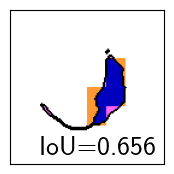

In [419]:
img, max_IoU, name = vis_IoU(shapley_values_aa, auc_IoU_aa['max_IoU_heatmap_threshold'], ground_truth), np.max(auc_IoU_aa['Y']), 'AA'
# img, max_IoU, name = vis_IoU(shapley_values_bpt, auc_IoU_bpt[2], ground_truth), np.max(auc_IoU_bpt[1]), 'BPT'
plt.figure(figsize=(2,2))
plt.imshow(img)

marked_h = mark_boundaries(np.tile((255,255,255,0), (img.shape[0],img.shape[1],1)), ground_truth, 
                             mode='thick', color=(0,0,0,1))
plt.imshow(marked_h)

plt.text(25,120, f'IoU={max_IoU:.3}', fontsize=20)
plt.xticks([]) ; plt.yticks([])
plt.savefig(f'paper_figures/figure_2_C_IoU_{name}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
# plt.savefig(f'IoU_BPT_{name}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

### Figure 3: C (BPT)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


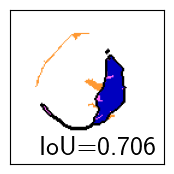

In [420]:
# img, max_IoU, name = vis_IoU(shapley_values_aa, auc_IoU_aa[2], ground_truth), np.max(auc_IoU_aa[1]), 'AA'
img, max_IoU, name = vis_IoU(shapley_values_bpt, auc_IoU_bpt['max_IoU_heatmap_threshold'], ground_truth), np.max(auc_IoU_bpt['Y']), 'BPT'
plt.figure(figsize=(2,2))
plt.imshow(img)
marked_h = mark_boundaries(np.tile((255,255,255,0), (img.shape[0],img.shape[1],1)), ground_truth, 
                             mode='thick', color=(0,0,0,1))
plt.imshow(marked_h)
plt.text(25,120, f'IoU={max_IoU:.3}', fontsize=20)
plt.xticks([]) ; plt.yticks([])
plt.savefig(f'paper_figures/figure_2_C_IoU_{name}.svg', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()

## END